In [2]:
#Import Libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression
from sklearn.linear_model import LinearRegression

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Load Dataset
df = pd.read_csv("HealthcareInsuranceClaim.csv")

In [4]:
df.head() # give the first n records

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


In [5]:
df.tail() # give the last n records

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
20095,96935977,XAI044413092,6472,2024-03-12,2024-02-25,2025-11-05,1182670.52,9,Male,Jacksonville,...,Rehab/Skilled Nursing,0,Emergency Room,3961.31,973.40,0,5,441.98,False,True
20096,11620007,XAI604243002,878,2024-10-19,2024-09-07,2029-09-20,1225019.60,60,Other,Los Angeles,...,Against Medical Advice,58,Inpatient,3383.95,998.72,0,0,602.85,True,False
20097,71153195,XAI115939441,4913,2022-04-05,2022-02-28,2026-03-23,1320858.11,15,Other,Chicago,...,Home,0,Outpatient,18.69,713.95,0,5,585.15,True,True
20098,58683401,XAI213569144,13498,2024-10-04,2024-09-26,2028-11-03,484552.40,41,Other,New York,...,Transfer to another facility,0,Emergency Room,3165.91,761.46,0,11,338.57,False,False
20099,72839302,XAI771983990,12690,2024-09-30,2024-08-04,2025-07-28,166117.59,57,Female,San Antonio,...,Home,0,Laboratory,4177.15,769.07,0,13,931.32,True,False


In [7]:
#Data Understanding
df.shape

(20100, 30)

In [8]:
#Columns
df.columns

Index(['Patient_ID', 'Policy_Number', 'Claim_ID', 'Claim_Date', 'Service_Date',
       'Policy_Expiration_Date', 'Claim_Amount', 'Patient_Age',
       'Patient_Gender', 'Patient_City', 'Patient_State', 'Hospital_ID',
       'Provider_Type', 'Provider_Specialty', 'Provider_City',
       'Provider_State', 'Diagnosis_Code', 'Procedure_Code',
       'Number_of_Procedures', 'Admission_Type', 'Discharge_Type',
       'Length_of_Stay_Days', 'Service_Type', 'Deductible_Amount',
       'CoPay_Amount', 'Number_of_Previous_Claims_Patient',
       'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles',
       'Claim_Submitted_Late', 'Is_Fraudulent'],
      dtype='object')

In [9]:
#Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Patient_ID                          20100 non-null  int64  
 1   Policy_Number                       20100 non-null  object 
 2   Claim_ID                            20100 non-null  int64  
 3   Claim_Date                          20100 non-null  object 
 4   Service_Date                        20100 non-null  object 
 5   Policy_Expiration_Date              20100 non-null  object 
 6   Claim_Amount                        20100 non-null  float64
 7   Patient_Age                         20100 non-null  int64  
 8   Patient_Gender                      20100 non-null  object 
 9   Patient_City                        20100 non-null  object 
 10  Patient_State                       20100 non-null  object 
 11  Hospital_ID                         20100

In [10]:
"""
This tells us:

column names
data types
number of non-null values
memory usage """

'\nThis tells us:\n\ncolumn names\ndata types\nnumber of non-null values\nmemory usage '

In [11]:
#Data types
df.dtypes

Patient_ID                              int64
Policy_Number                          object
Claim_ID                                int64
Claim_Date                             object
Service_Date                           object
Policy_Expiration_Date                 object
Claim_Amount                          float64
Patient_Age                             int64
Patient_Gender                         object
Patient_City                           object
Patient_State                          object
Hospital_ID                             int64
Provider_Type                          object
Provider_Specialty                     object
Provider_City                          object
Provider_State                         object
Diagnosis_Code                         object
Procedure_Code                          int64
Number_of_Procedures                    int64
Admission_Type                         object
Discharge_Type                         object
Length_of_Stay_Days               

In [12]:
#Number of unique values
df.nunique()

Patient_ID                            19994
Policy_Number                         20000
Claim_ID                              20000
Claim_Date                             2019
Service_Date                           2093
Policy_Expiration_Date                 3479
Claim_Amount                          19999
Patient_Age                              91
Patient_Gender                            3
Patient_City                             20
Patient_State                            20
Hospital_ID                            1000
Provider_Type                             6
Provider_Specialty                       10
Provider_City                            20
Provider_State                           20
Diagnosis_Code                           20
Procedure_Code                           20
Number_of_Procedures                     10
Admission_Type                            5
Discharge_Type                            5
Length_of_Stay_Days                      61
Service_Type                    

In [13]:
#For one column check unique values
df["Provider_Type"].nunique()

6

In [15]:
#Value counts
df["Provider_Type"].value_counts()


Provider_Type
Specialist Office    5084
Pharmacy             3084
Urgent Care          3036
Clinic               3004
Hospital             2972
Laboratory           2920
Name: count, dtype: int64

In [16]:
#For fraud value counts:

df["Is_Fraudulent"].value_counts()

Is_Fraudulent
False    15089
True      5011
Name: count, dtype: int64

In [17]:
#Percentage
df["Is_Fraudulent"].value_counts(normalize=True) * 100

Is_Fraudulent
False    75.069652
True     24.930348
Name: proportion, dtype: float64

In [27]:
#Count null values in each column:
df.isnull().sum()

Patient_ID                            0
Policy_Number                         0
Claim_ID                              0
Claim_Date                            0
Service_Date                          0
Policy_Expiration_Date                0
Claim_Amount                          0
Patient_Age                           0
Patient_Gender                        0
Patient_City                          0
Patient_State                         0
Hospital_ID                           0
Provider_Type                         0
Provider_Specialty                    0
Provider_City                         0
Provider_State                        0
Diagnosis_Code                        0
Procedure_Code                        0
Number_of_Procedures                  0
Admission_Type                        0
Discharge_Type                        0
Length_of_Stay_Days                   0
Service_Type                          0
Deductible_Amount                     0
CoPay_Amount                          0


In [28]:
#Find the total number of null values in the entire dataset
df.isnull().sum().sum()

np.int64(0)

In [29]:
#Null percentage of each column

#This is useful during data cleaning/EDA:

df.isnull().mean() * 100

Patient_ID                            0.0
Policy_Number                         0.0
Claim_ID                              0.0
Claim_Date                            0.0
Service_Date                          0.0
Policy_Expiration_Date                0.0
Claim_Amount                          0.0
Patient_Age                           0.0
Patient_Gender                        0.0
Patient_City                          0.0
Patient_State                         0.0
Hospital_ID                           0.0
Provider_Type                         0.0
Provider_Specialty                    0.0
Provider_City                         0.0
Provider_State                        0.0
Diagnosis_Code                        0.0
Procedure_Code                        0.0
Number_of_Procedures                  0.0
Admission_Type                        0.0
Discharge_Type                        0.0
Length_of_Stay_Days                   0.0
Service_Type                          0.0
Deductible_Amount                 

In [30]:
#Interview explanation

#I first performed data profiling to understand the dimensions, data types, cardinality, missing values and target distribution before starting the analysis.

In [31]:
#Foundation Statistics

In [33]:
#Descriptive statistics:

df.describe()

,Patient_ID,Claim_ID,Claim_Amount,Patient_Age,Hospital_ID,Procedure_Code,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
count,2.010000e+04,20100.000000,2.010000e+04,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,5.528158e+07,10005.580348,1.245349e+06,45.104925,500.204179,92463.849851,5.510249,4.975821,2508.487758,499.665796,0.000299,10.027910,499.480532
std,2.606038e+07,5774.135663,6.983001e+05,26.300942,288.437500,8151.470654,2.882847,13.239804,1443.579069,288.397727,0.017275,6.622332,289.745360
min,1.000265e+07,1.000000,5.516780e+03,0.000000,1.000000,71045.000000,1.000000,0.000000,0.030000,0.020000,0.000000,0.000000,0.020000
25%,3.266819e+07,5005.750000,6.674103e+05,22.000000,251.000000,93040.000000,3.000000,0.000000,1251.440000,248.800000,0.000000,5.000000,246.380000
50%,5.551009e+07,10008.500000,1.221707e+06,45.000000,500.000000,93571.000000,6.000000,0.000000,2508.875000,499.950000,0.000000,10.000000,498.410000
75%,7.814105e+07,15011.250000,1.835603e+06,68.000000,752.000000,99204.000000,8.000000,0.000000,3755.080000,750.040000,0.000000,15.000000,751.000000
max,9.998440e+07,20000.000000,2.499689e+06,90.000000,1000.000000,99284.000000,10.000000,60.000000,4999.870000,999.880000,1.000000,34.000000,999.980000


In [34]:
#For a particular column:

df["Claim_Amount"].describe()

count    2.010000e+04
mean     1.245349e+06
std      6.983001e+05
min      5.516780e+03
25%      6.674103e+05
50%      1.221707e+06
75%      1.835603e+06
max      2.499689e+06
Name: Claim_Amount, dtype: float64

In [35]:
#Mean:

df["Claim_Amount"].mean()

#Meaning:

#Average claim amount.

np.float64(1245349.0328597017)

In [36]:
#Median:

df["Claim_Amount"].median()

#Median is useful because it is less affected by extreme values.

np.float64(1221706.875)

In [37]:
#Mode
df["Provider_Type"].mode()

0    Specialist Office
Name: Provider_Type, dtype: object

In [38]:
#Standard deviation:

df["Claim_Amount"].std()

#It tells us how spread out claim amounts are.

np.float64(698300.0546141404)

In [39]:
#Variance
df["Claim_Amount"].var()

np.float64(487622966274.1116)

In [42]:
#Minimum and maximum
df["Claim_Amount"].min()

np.float64(5516.78)

In [43]:
df["Claim_Amount"].max()

np.float64(2499688.55)

In [44]:
#Percentiles
df["Claim_Amount"].quantile(0.25)

np.float64(667410.2825)

In [45]:
#IQR
Q1 = df["Claim_Amount"].quantile(0.25)
Q3 = df["Claim_Amount"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
#Why?

#IQR helps us identify potential outliers.

Q1: 667410.2825
Q3: 1835603.445
IQR: 1168193.1625


In [46]:
#Data Quality
#Missing values
df.isnull().sum()

Patient_ID                            0
Policy_Number                         0
Claim_ID                              0
Claim_Date                            0
Service_Date                          0
Policy_Expiration_Date                0
Claim_Amount                          0
Patient_Age                           0
Patient_Gender                        0
Patient_City                          0
Patient_State                         0
Hospital_ID                           0
Provider_Type                         0
Provider_Specialty                    0
Provider_City                         0
Provider_State                        0
Diagnosis_Code                        0
Procedure_Code                        0
Number_of_Procedures                  0
Admission_Type                        0
Discharge_Type                        0
Length_of_Stay_Days                   0
Service_Type                          0
Deductible_Amount                     0
CoPay_Amount                          0


In [47]:
#Percentage:

(df.isnull().sum() / len(df)) * 100

Patient_ID                            0.0
Policy_Number                         0.0
Claim_ID                              0.0
Claim_Date                            0.0
Service_Date                          0.0
Policy_Expiration_Date                0.0
Claim_Amount                          0.0
Patient_Age                           0.0
Patient_Gender                        0.0
Patient_City                          0.0
Patient_State                         0.0
Hospital_ID                           0.0
Provider_Type                         0.0
Provider_Specialty                    0.0
Provider_City                         0.0
Provider_State                        0.0
Diagnosis_Code                        0.0
Procedure_Code                        0.0
Number_of_Procedures                  0.0
Admission_Type                        0.0
Discharge_Type                        0.0
Length_of_Stay_Days                   0.0
Service_Type                          0.0
Deductible_Amount                 

In [48]:
#Duplicate Detection
df.duplicated().sum()

np.int64(28)

In [49]:
#Remove Duplicates:
df = df.drop_duplicates()

In [50]:
df.duplicated().sum()

np.int64(0)

In [32]:
#Date Conversion

#Currently dates are strings.

#Convert:

date_columns = [
    "Claim_Date",
    "Service_Date",
    "Policy_Expiration_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [52]:
df.dtypes

Patient_ID                                     int64
Policy_Number                                 object
Claim_ID                                       int64
Claim_Date                            datetime64[ns]
Service_Date                          datetime64[ns]
Policy_Expiration_Date                datetime64[ns]
Claim_Amount                                 float64
Patient_Age                                    int64
Patient_Gender                                object
Patient_City                                  object
Patient_State                                 object
Hospital_ID                                    int64
Provider_Type                                 object
Provider_Specialty                            object
Provider_City                                 object
Provider_State                                object
Diagnosis_Code                                object
Procedure_Code                                 int64
Number_of_Procedures                          

In [58]:
#Data Validation

#Check impossible ages:

df[df["Patient_Age"] == 0]

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
6,46024079,XAI987257433,669,2021-12-16,2021-10-16,2026-08-30,994761.24,0,Other,Los Angeles,...,Home,0,Laboratory,3028.31,110.26,0,1,270.42,True,True
208,30154955,XAI612657943,7657,2024-12-31,2024-12-28,2028-04-14,1413600.46,0,Male,San Diego,...,Transfer to another facility,0,Outpatient,3099.52,209.94,0,8,516.03,False,False
218,63309381,XAI723486701,4876,2022-04-13,2022-03-21,2027-03-15,1218464.53,0,Male,New York,...,Deceased,0,Emergency Room,4325.31,244.62,0,2,234.22,False,True
334,64211504,XAI431483005,4473,2021-11-16,2021-09-03,2023-05-17,1742723.03,0,Other,Houston,...,Against Medical Advice,0,Emergency Room,622.69,451.00,0,5,111.48,True,False
383,97239435,XAI595993606,2649,2021-10-06,2021-07-16,2026-10-01,477190.28,0,Female,Denver,...,Rehab/Skilled Nursing,0,Ambulance,217.83,942.95,0,2,871.06,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19694,71470869,XAI729634229,13053,2023-11-30,2023-11-13,2026-08-13,736620.36,0,Male,Washington,...,Rehab/Skilled Nursing,0,Pharmacy,2888.93,112.02,0,11,431.41,False,False
19744,20525650,XAI569474012,6545,2025-04-15,2025-04-13,2026-02-20,914636.39,0,Other,Phoenix,...,Transfer to another facility,0,Pharmacy,991.73,610.24,0,8,698.17,False,False
19950,13591524,XAI391709352,18000,2023-02-07,2023-01-06,2023-07-22,2456305.66,0,Male,Charlotte,...,Deceased,0,Emergency Room,764.21,687.54,0,20,446.09,True,False
19970,47004448,XAI708396014,18271,2020-01-10,2019-10-13,2021-06-22,799496.88,0,Male,Houston,...,Against Medical Advice,0,Emergency Room,581.14,693.12,0,17,418.48,True,True


In [70]:
#We should not blindly delete them.

#For a project, we can flag them:

df["Age_Invalid"] = df["Patient_Age"] <= 0

In [71]:
#Then:

df["Age_Invalid"].value_counts()

#You can explain:

#"I identified potentially invalid age values and treated them as data-quality flags rather than automatically deleting them."

Age_Invalid
False    19845
True       227
Name: count, dtype: int64

In [72]:
#Check negative claims
df[df["Claim_Amount"] < 0]

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent,Age_Invalid,Claim_Year,Claim_Month,Claim_Month_Name,Claim_Day


In [73]:
#Check invalid length of stay
df[df["Length_of_Stay_Days"] < 0]

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent,Age_Invalid,Claim_Year,Claim_Month,Claim_Month_Name,Claim_Day


In [74]:
#Check date consistency
df[df["Service_Date"] > df["Claim_Date"]]

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent,Age_Invalid,Claim_Year,Claim_Month,Claim_Month_Name,Claim_Day


In [33]:
#Data Engineering

#Now create useful date features.

#Claim year
df["Claim_Year"] = df["Claim_Date"].dt.year

In [34]:
#Claim month
df["Claim_Month"] = df["Claim_Date"].dt.month

In [35]:
#Month name
df["Claim_Month_Name"] = df["Claim_Date"].dt.strftime("%B")

In [36]:
#Day of week
df["Claim_Day"] = df["Claim_Date"].dt.day_name()

In [77]:
#Service-to-claim delay
df["Days_Service_to_Claim"] = (
    df["Claim_Date"] - df["Service_Date"]
).dt.days

#This answers:

#How long after the service was the claim submitted?

In [78]:
#Days before policy expiry
df["Days_to_Policy_Expiry"] = (
    df["Policy_Expiration_Date"] -
    df["Claim_Date"]
).dt.days

In [84]:
#Pandas Operations

#Now deliberately demonstrate important Pandas operations.

#Filtering
high_claims = df[df["Claim_Amount"] > 1000000]

In [85]:
#Multiple conditions
fraud_high_claims = df[
    (df["Is_Fraudulent"] == True) &
    (df["Claim_Amount"] > 1000000)
]

In [86]:
#Sorting
df.sort_values(
    by="Claim_Amount",
    ascending=False
).head(10)

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
265,94876757,XAI766259601,1226,2024-08-11,2024-06-15,2027-04-21,2499688.55,4,Female,Los Angeles,...,Transfer to another facility,0,Outpatient,2925.34,982.72,0,2,733.43,True,True
13139,91981724,XAI940114584,4864,2020-04-23,2020-04-12,2023-07-25,2499638.03,4,Female,Indianapolis,...,Deceased,0,Emergency Room,3375.69,451.35,0,6,261.94,False,False
4620,75371970,XAI463024868,831,2022-03-05,2022-01-27,2027-01-10,2499552.51,16,Other,Columbus,...,Rehab/Skilled Nursing,14,Inpatient,1956.49,686.34,0,1,970.55,True,False
18957,20525556,XAI698672438,1517,2023-12-03,2023-11-03,2028-04-28,2499530.49,8,Female,Phoenix,...,Against Medical Advice,0,Outpatient,1961.53,534.14,0,0,838.29,False,False
35,50313652,XAI447222818,11460,2022-03-22,2022-02-16,2026-01-22,2499394.04,17,Other,New York,...,Against Medical Advice,0,Outpatient,2018.86,380.95,0,8,807.28,True,False
5536,24524978,XAI654566269,12274,2021-07-28,2021-06-25,2022-02-13,2499333.13,42,Other,Philadelphia,...,Rehab/Skilled Nursing,0,Pharmacy,2823.83,314.92,0,18,533.80,True,False
14697,42271711,XAI596454660,10615,2024-12-04,2024-10-21,2025-12-18,2499319.20,68,Male,Dallas,...,Transfer to another facility,0,Ambulance,503.97,702.53,0,16,474.02,True,False
7338,64575134,XAI102958810,9159,2023-03-20,2023-02-05,2026-10-01,2499310.17,2,Female,Washington,...,Rehab/Skilled Nursing,0,Emergency Room,4274.43,906.42,0,11,286.10,True,False
19256,71452426,XAI049272443,19488,2025-07-08,2025-05-29,2025-09-04,2499259.89,32,Female,Phoenix,...,Home,0,Outpatient,2653.90,804.64,0,20,930.56,True,False
9009,76199015,XAI895356043,16406,2022-05-03,2022-03-26,2025-11-23,2499055.04,2,Other,Chicago,...,Rehab/Skilled Nursing,0,Outpatient,1431.94,698.23,0,22,601.27,True,False


In [87]:
#GroupBy
df.groupby("Provider_Type")["Claim_Amount"].mean()

Provider_Type
Clinic               1.275745e+06
Hospital             1.254525e+06
Laboratory           1.258946e+06
Pharmacy             1.292735e+06
Specialist Office    1.166074e+06
Urgent Care          1.277829e+06
Name: Claim_Amount, dtype: float64

In [88]:
#Multiple aggregations
df.groupby("Provider_Type")["Claim_Amount"].agg(
    ["count", "mean", "sum", "min", "max"]
)

,count,mean,sum,min,max
Provider_Type,,,,,
Clinic,3004,1.275745e+06,3.832339e+09,6174.08,2499688.55
Hospital,2972,1.254525e+06,3.728450e+09,5741.84,2499319.20
Laboratory,2920,1.258946e+06,3.676124e+09,6122.86,2497891.07
Pharmacy,3084,1.292735e+06,3.986796e+09,5516.78,2499552.51
Specialist Office,5084,1.166074e+06,5.928319e+09,6762.12,2499638.03
Urgent Care,3036,1.277829e+06,3.879489e+09,6078.25,2497342.57


In [89]:
#Pivot table
pd.pivot_table(
    df,
    values="Claim_Amount",
    index="Provider_Type",
    columns="Is_Fraudulent",
    aggfunc="mean"
)

Is_Fraudulent,False,True
Provider_Type,,
Clinic,1.227460e+06,1.515257e+06
Hospital,1.211157e+06,1.473666e+06
Laboratory,1.225645e+06,1.432983e+06
Pharmacy,1.244021e+06,1.547525e+06
Specialist Office,1.221755e+06,1.110128e+06
Urgent Care,1.232914e+06,1.497181e+06


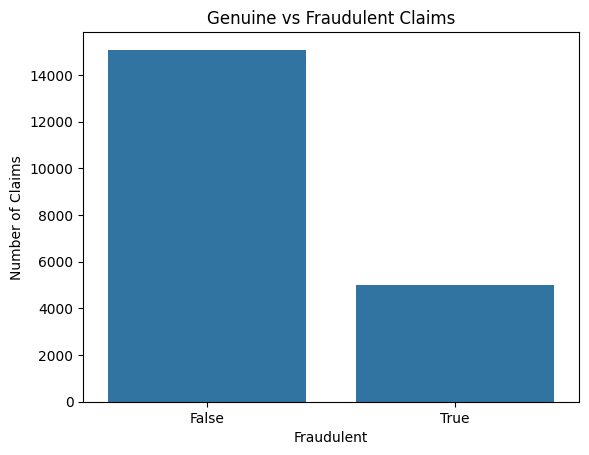

In [90]:
#EDA

#Now the actual exploratory analysis starts.

#Fraud distribution
sns.countplot(
    data=df,
    x="Is_Fraudulent"
)

plt.title("Genuine vs Fraudulent Claims")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Claims")
plt.show()

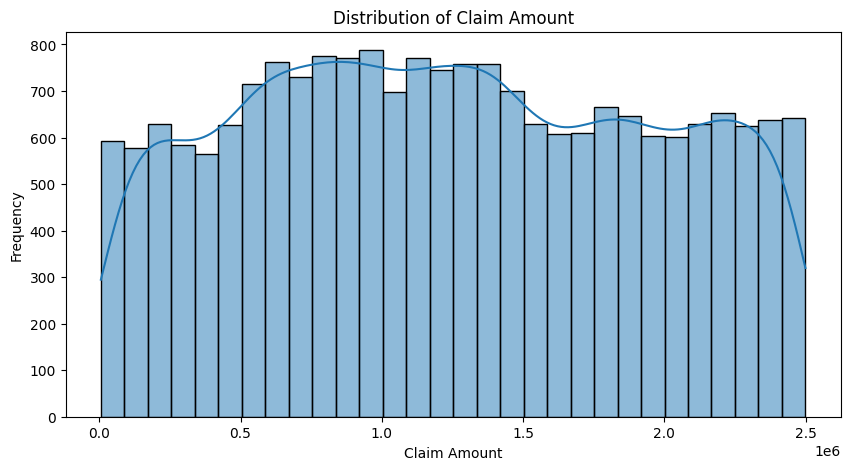

In [91]:
#Claim amount distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Claim_Amount",
    bins=30,
    kde=True
)

plt.title("Distribution of Claim Amount")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")

plt.show()

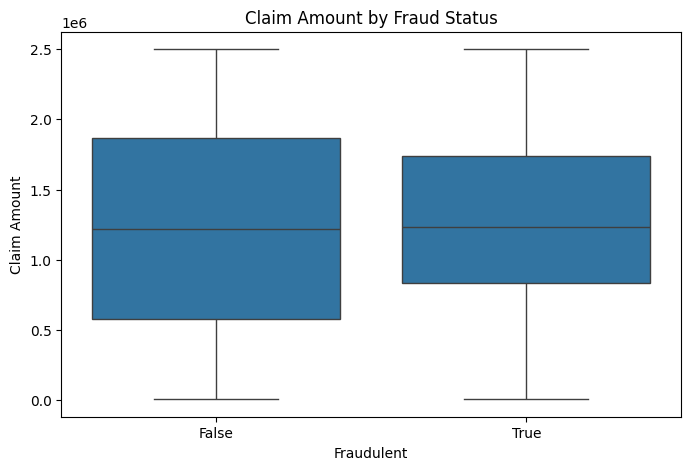

In [92]:
#Claim amount vs fraud
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Is_Fraudulent",
    y="Claim_Amount"
)

plt.title("Claim Amount by Fraud Status")
plt.xlabel("Fraudulent")
plt.ylabel("Claim Amount")

plt.show()

In [93]:
#Question answered

#Do fraudulent and genuine claims have different claim-amount distributions?

In [4]:
#Fraud by provider type
fraud_provider = pd.crosstab(
    df["Provider_Type"],
    df["Is_Fraudulent"],
    normalize="index"
) * 100

fraud_provider

Is_Fraudulent,False,True
Provider_Type,,
Clinic,83.222370,16.777630
Hospital,83.479139,16.520861
Laboratory,83.938356,16.061644
Pharmacy,83.949416,16.050584
Specialist Office,50.118017,49.881983
Urgent Care,83.003953,16.996047


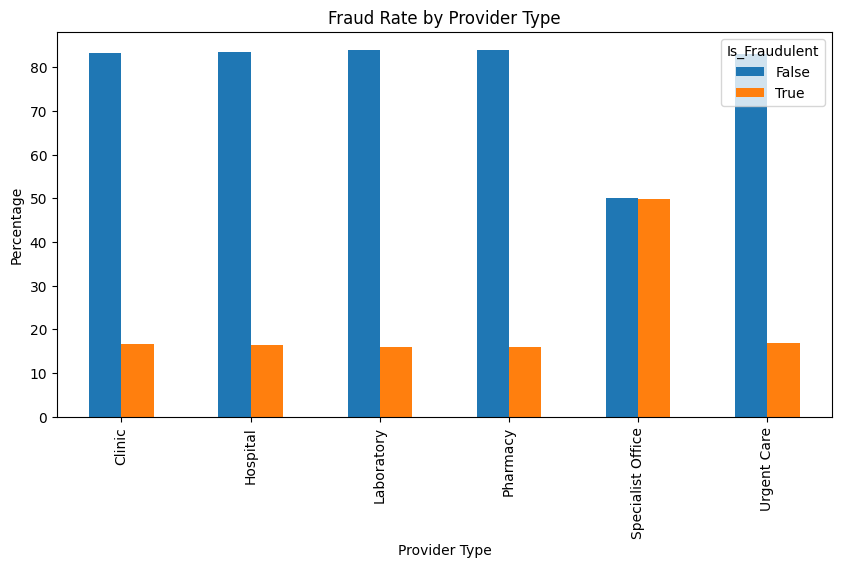

In [5]:
#Visualize:

fraud_provider.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fraud Rate by Provider Type")
plt.ylabel("Percentage")
plt.xlabel("Provider Type")

plt.show()

#Your dataset shows Specialist Office with a notably higher observed fraud rate than the other provider types.

In [6]:
#Fraud by specialty
specialty_fraud = (
    df.groupby("Provider_Specialty")["Is_Fraudulent"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

specialty_fraud

Provider_Specialty
Cardiology          46.549875
Orthopedics         45.652174
General Practice    17.790368
Pediatrics          17.540891
Physical Therapy    17.344173
Neurology           16.979111
Psychiatry          16.778149
Oncology            16.767455
Radiology           16.164818
Dermatology         16.148391
Name: Is_Fraudulent, dtype: float64

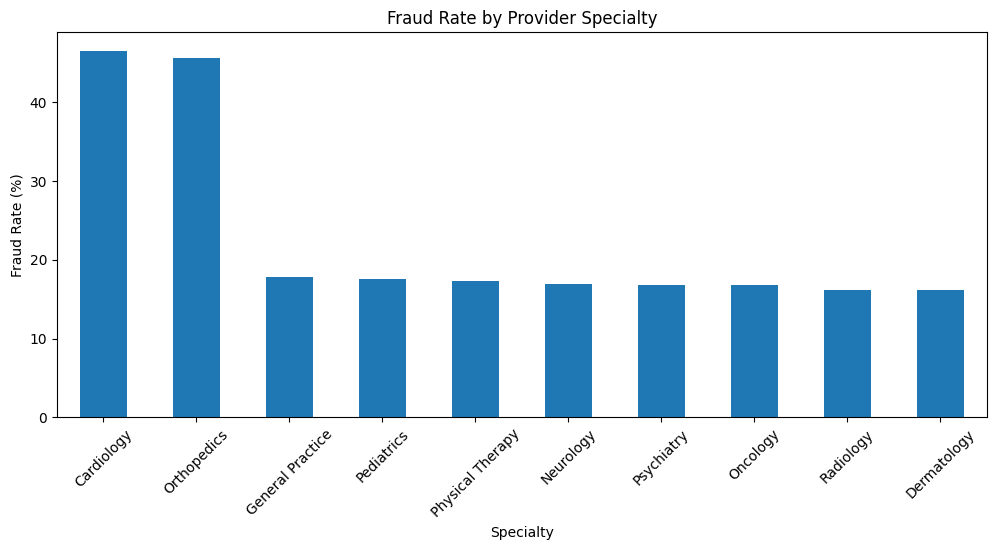

In [7]:
#Plot:

specialty_fraud.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Fraud Rate by Provider Specialty")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Specialty")

plt.xticks(rotation=45)

plt.show()

In [8]:
#Fraud by service type
service_fraud = (
    df.groupby("Service_Type")["Is_Fraudulent"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

service_fraud

Service_Type
Laboratory        28.152141
Emergency Room    27.170036
Ambulance         27.078385
Outpatient        26.375598
Pharmacy          26.309594
Inpatient         14.268330
Name: Is_Fraudulent, dtype: float64

In [9]:
#Fraud by admission type
admission_fraud = (
    df.groupby("Admission_Type")["Is_Fraudulent"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

admission_fraud

Admission_Type
Elective     32.322552
Urgent       32.172924
Trauma       19.869530
Newborn      19.776017
Emergency    17.965755
Name: Is_Fraudulent, dtype: float64

In [38]:
#Monthly trend
monthly_claims = (
    df.groupby("Claim_Month")
    .agg(
        Total_Claims=("Claim_ID", "count"),
        Fraudulent_Claims=("Is_Fraudulent", "sum"),
        Total_Amount=("Claim_Amount", "sum")
    )
)

monthly_claims

,Total_Claims,Fraudulent_Claims,Total_Amount
Claim_Month,,,
1,1797,459,2.233402e+09
2,1625,415,2.018808e+09
3,1834,449,2.219228e+09
4,1781,413,2.233548e+09
5,1868,471,2.294645e+09
6,1845,470,2.292279e+09
7,1694,428,2.120707e+09
8,1519,371,1.891758e+09
9,1527,393,1.908704e+09


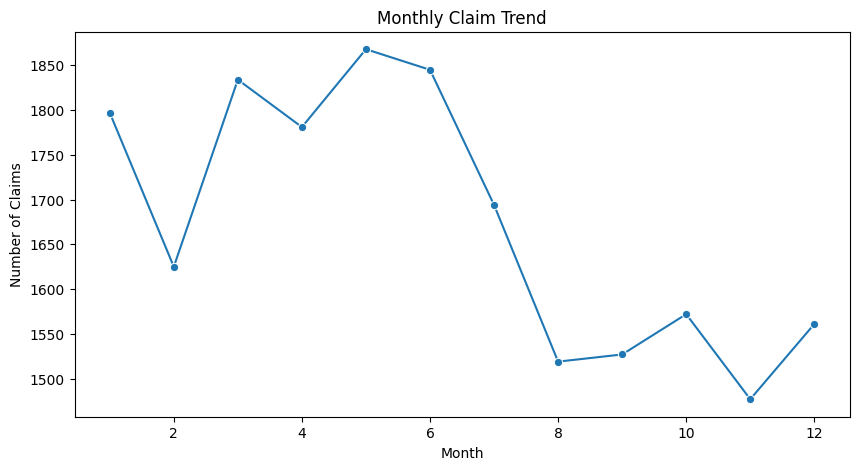

In [39]:
#Plot:

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_claims,
    x=monthly_claims.index,
    y="Total_Claims",
    marker="o"
)

plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Number of Claims")

plt.show()

In [40]:
#Correlation Analysis

#Select numerical columns:

numeric_columns = [
    "Claim_Amount",
    "Patient_Age",
    "Number_of_Procedures",
    "Length_of_Stay_Days",
    "Deductible_Amount",
    "CoPay_Amount",
    "Number_of_Previous_Claims_Patient",
    "Number_of_Previous_Claims_Provider",
    "Provider_Patient_Distance_Miles"
]

In [41]:
#Correlation:

correlation = df[numeric_columns].corr()

correlation

,Claim_Amount,Patient_Age,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
Claim_Amount,1.000000,0.001708,-0.061722,0.016990,0.009833,-0.002607,0.001211,-0.000577,0.010726
Patient_Age,0.001708,1.000000,0.006989,-0.013438,-0.000770,0.002008,0.008472,-0.003455,0.007546
Number_of_Procedures,-0.061722,0.006989,1.000000,-0.010301,0.005160,-0.004129,-0.004058,-0.001945,-0.007043
Length_of_Stay_Days,0.016990,-0.013438,-0.010301,1.000000,-0.008690,-0.003466,-0.001056,0.005226,-0.004176
Deductible_Amount,0.009833,-0.000770,0.005160,-0.008690,1.000000,0.003201,0.001906,0.006055,0.000274
CoPay_Amount,-0.002607,0.002008,-0.004129,-0.003466,0.003201,1.000000,-0.009988,0.001273,0.004932
Number_of_Previous_Claims_Patient,0.001211,0.008472,-0.004058,-0.001056,0.001906,-0.009988,1.000000,0.003841,0.011863
Number_of_Previous_Claims_Provider,-0.000577,-0.003455,-0.001945,0.005226,0.006055,0.001273,0.003841,1.000000,0.002788
Provider_Patient_Distance_Miles,0.010726,0.007546,-0.007043,-0.004176,0.000274,0.004932,0.011863,0.002788,1.000000


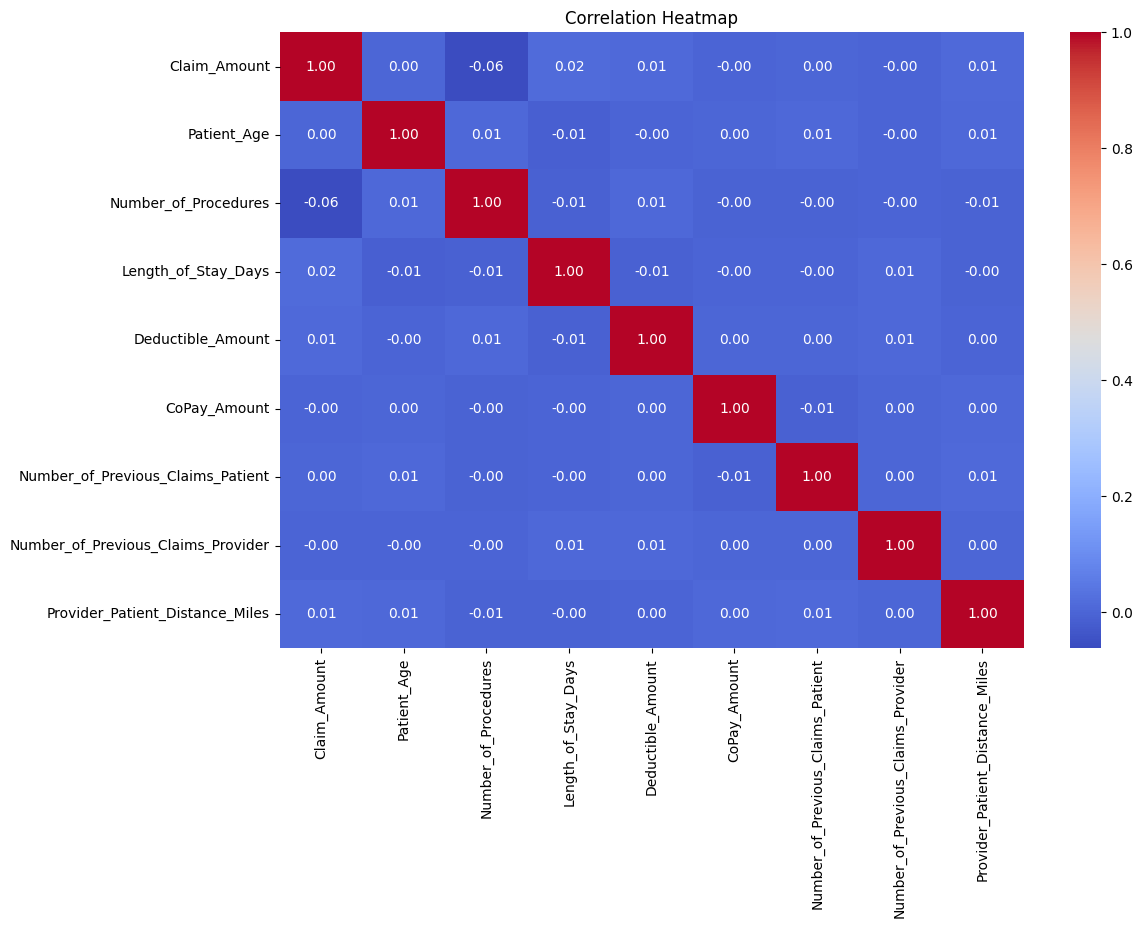

In [42]:
#Heatmap:

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [43]:
"""Interview explanation

Correlation helped me understand relationships between numerical variables and identify potentially useful predictors before modeling.

Remember: correlation does not prove causation."""

'Interview explanation\n\nCorrelation helped me understand relationships between numerical variables and identify potentially useful predictors before modeling.\n\nRemember: correlation does not prove causation.'

In [44]:
#Outlier Analysis

#Use IQR.

Q1 = df["Claim_Amount"].quantile(0.25)
Q3 = df["Claim_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Claim_Amount"] < lower) |
    (df["Claim_Amount"] > upper)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 0


In [45]:
"""
Important

Don't automatically remove these.

In insurance analysis, an extremely large claim can be a real business event.

You should investigate it."""

"\nImportant\n\nDon't automatically remove these.\n\nIn insurance analysis, an extremely large claim can be a real business event.\n\nYou should investigate it."

In [46]:
#Feature Engineering

#Now create ML/business features.

df["Claim_Amount_per_Procedure"] = (
    df["Claim_Amount"] /
    df["Number_of_Procedures"].replace(0, np.nan)
)

In [47]:
#Previous claims:

df["Previous_Claims_Total"] = (
    df["Number_of_Previous_Claims_Patient"] +
    df["Number_of_Previous_Claims_Provider"]
)

In [48]:
#Patient claim frequency:

df["Patient_Claim_Frequency"] = (
    df["Number_of_Previous_Claims_Patient"] + 1
)

In [49]:
#Provider claim frequency:

df["Provider_Claim_Frequency"] = (
    df["Number_of_Previous_Claims_Provider"] + 1
)

In [50]:
#High-value flag:

Q1 = df["Claim_Amount"].quantile(0.25)
Q3 = df["Claim_Amount"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df["High_Value_Claim"] = (
    df["Claim_Amount"] > upper_bound
)

In [51]:
#Multiple procedures:

df["Multiple_Procedure_Claim"] = (
    df["Number_of_Procedures"] >= 5
)

In [52]:
#ML Preparation

#Now we start ML.

#Our target is:

y = df["Is_Fraudulent"]

In [53]:
#Remove target:

X = df.drop(columns=["Is_Fraudulent"])

In [54]:
#But do not use identifiers as predictive features.

#Remove:

drop_columns = [
    "Patient_ID",
    "Policy_Number",
    "Claim_ID",
    "Hospital_ID"
]

X = X.drop(columns=drop_columns)

#Also remove raw date columns after extracting useful date features.

In [55]:
"""Important Leakage Decision

This is extremely important for your interview.

We don't want the model learning from information that would not legitimately be available when assessing a claim.

For example, don't use:

Fraud_Reason
Investigation_Result
Fraud_Score generated after investigation. """

"Important Leakage Decision\n\nThis is extremely important for your interview.\n\nWe don't want the model learning from information that would not legitimately be available when assessing a claim.\n\nFor example, don't use:\n\nFraud_Reason\nInvestigation_Result\nFraud_Score generated after investigation. "

In [56]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [57]:
"""
Why stratify=y?

Because our target contains:

75.07% Genuine
24.93% Fraud

We want approximately the same class distribution in train and test."""

'\nWhy stratify=y?\n\nBecause our target contains:\n\n75.07% Genuine\n24.93% Fraud\n\nWe want approximately the same class distribution in train and test.'

In [58]:
#Preprocessing

#Separate numerical and categorical columns.

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns

In [59]:
#Create preprocessing:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [60]:
"""
Why scaling?

Especially for:

KNN
Logistic Regression

A claim amount of millions should not dominate a variable such as age simply because of its numerical scale. """

'\nWhy scaling?\n\nEspecially for:\n\nKNN\nLogistic Regression\n\nA claim amount of millions should not dominate a variable such as age simply because of its numerical scale. '

In [61]:
#Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:,1]

In [62]:
#Classification report:

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

       False       0.84      0.95      0.89      3018
        True       0.74      0.47      0.57      1002

    accuracy                           0.83      4020
   macro avg       0.79      0.71      0.73      4020
weighted avg       0.82      0.83      0.81      4020



In [63]:
#ROC-AUC:

roc_auc_score(
    y_test,
    y_prob_logistic
)

0.8078693507616972

In [64]:
#KNN
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

In [65]:
#Evaluate:

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

       False       0.85      0.88      0.86      3018
        True       0.59      0.53      0.56      1002

    accuracy                           0.79      4020
   macro avg       0.72      0.71      0.71      4020
weighted avg       0.79      0.79      0.79      4020



In [66]:
#Decision Tree
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=10
            )
        )
    ]
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [67]:
#Evaluate:

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

       False       0.87      0.96      0.91      3018
        True       0.82      0.55      0.66      1002

    accuracy                           0.86      4020
   macro avg       0.84      0.76      0.79      4020
weighted avg       0.86      0.86      0.85      4020



In [68]:
#Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [69]:
#Evaluate:

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

       False       0.86      0.99      0.92      3018
        True       0.94      0.51      0.66      1002

    accuracy                           0.87      4020
   macro avg       0.90      0.75      0.79      4020
weighted avg       0.88      0.87      0.86      4020



In [70]:
#ROC-AUC:

roc_auc_score(
    y_test,
    y_prob_rf
)

0.8698160339361038

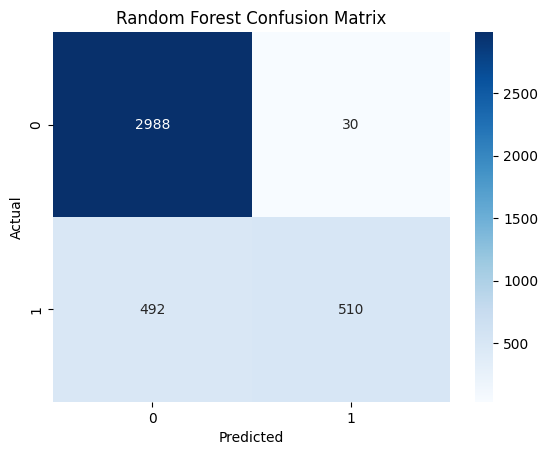

In [71]:
#Confusion Matrix for Random Forest:

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [72]:
"""
Understand it:

                Predicted
              Genuine  Fraud
Actual
Genuine          TN      FP
Fraud            FN      TP

For fraud detection:

TP → fraud correctly detected
FN → fraud missed
FP → genuine claim incorrectly flagged. """

'\nUnderstand it:\n\n                Predicted\n              Genuine  Fraud\nActual\nGenuine          TN      FP\nFraud            FN      TP\n\nFor fraud detection:\n\nTP → fraud correctly detected\nFN → fraud missed\nFP → genuine claim incorrectly flagged. '

In [73]:
#Compare All Classification Models
models = {
    "Logistic Regression": (
        logistic_model,
        y_pred_logistic,
        y_prob_logistic
    ),

    "KNN": (
        knn_model,
        y_pred_knn,
        y_prob_knn
    ),

    "Decision Tree": (
        dt_model,
        y_pred_dt,
        y_prob_dt
    ),

    "Random Forest": (
        rf_model,
        y_pred_rf,
        y_prob_rf
    )
}

In [74]:
results = []

for name, (model, predictions, probabilities) in models.items():

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1": f1_score(
            y_test,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

model_results = pd.DataFrame(results)

model_results.sort_values(
    "ROC_AUC",
    ascending=False
)

# This creates your model comparison table.

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Random Forest,0.870149,0.944444,0.508982,0.661479,0.869816
2,Decision Tree,0.859204,0.823442,0.553892,0.662291,0.851405
0,Logistic Regression,0.825622,0.738510,0.465070,0.570729,0.807869
1,KNN,0.793284,0.594895,0.534930,0.563321,0.768354


In [75]:
#Why Classification Report?

#Use:

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

"""It gives:

precision
recall
f1-score
support"""

              precision    recall  f1-score   support

       False       0.86      0.99      0.92      3018
        True       0.94      0.51      0.66      1002

    accuracy                           0.87      4020
   macro avg       0.90      0.75      0.79      4020
weighted avg       0.88      0.87      0.86      4020



'It gives:\n\nprecision\nrecall\nf1-score\nsupport'

In [76]:
"""
Precision:

Of the claims predicted as fraud, how many were actually fraud?

Recall:

Of all actual fraudulent claims, how many did we detect?

F1-score:

Balance between precision and recall.

Support:

Number of actual observations in each class.

"""

'\nPrecision:\n\nOf the claims predicted as fraud, how many were actually fraud?\n\nRecall:\n\nOf all actual fraudulent claims, how many did we detect?\n\nF1-score:\n\nBalance between precision and recall.\n\nSupport:\n\nNumber of actual observations in each class.\n\n'

In [77]:
"""
Linear Regression

Now we use ML for a different business problem.

Instead of predicting fraud:

Predict claim amount. """

'\nLinear Regression\n\nNow we use ML for a different business problem.\n\nInstead of predicting fraud:\n\nPredict claim amount. '

In [78]:
#Target:

y_reg = df["Claim_Amount"]

In [79]:
#Do not include:

#Claim_Amount
#Is_Fraudulent

In [80]:
X_reg = df.drop(
    columns=[
        "Claim_Amount",
        "Is_Fraudulent",
        "Patient_ID",
        "Policy_Number",
        "Claim_ID",
        "Hospital_ID"
    ]
)

In [81]:
#Split:

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [82]:
#Preprocessing:

numeric_reg = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_reg = X_reg.select_dtypes(
    include=["object", "bool"]
).columns

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_reg
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_reg
        )
           ]
)

In [83]:
#Model:

linear_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train_reg,
    y_train_reg
)

y_pred_reg = linear_model.predict(
    X_test_reg
)

In [84]:
#Evaluate:

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 466390.03274860495
MSE: 307332051565.1204
RMSE: 554375.3706335811
R²: 0.3754288638074682


In [85]:
"""Interview explanation

I used Linear Regression for a separate regression problem: estimating claim amount. Fraud detection is a classification problem, whereas claim amount prediction is a continuous-value regression problem."""

'Interview explanation\n\nI used Linear Regression for a separate regression problem: estimating claim amount. Fraud detection is a classification problem, whereas claim amount prediction is a continuous-value regression problem.'

In [86]:
"""
K-Means

K-Means is not used to predict fraud directly.

We'll use it for claim/customer segmentation. """

"\nK-Means\n\nK-Means is not used to predict fraud directly.\n\nWe'll use it for claim/customer segmentation. "

In [4]:
#Select numerical behavioral variables:

cluster_features = [
    "Claim_Amount",
    "Patient_Age",
    "Number_of_Procedures",
    "Length_of_Stay_Days",
    "Number_of_Previous_Claims_Patient",
    "Number_of_Previous_Claims_Provider",
    "Provider_Patient_Distance_Miles"
]

In [5]:
#Scale:

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    df[cluster_features]
)

In [6]:
#Find K using Elbow Method
inertias = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    inertias.append(
        kmeans.inertia_
    )

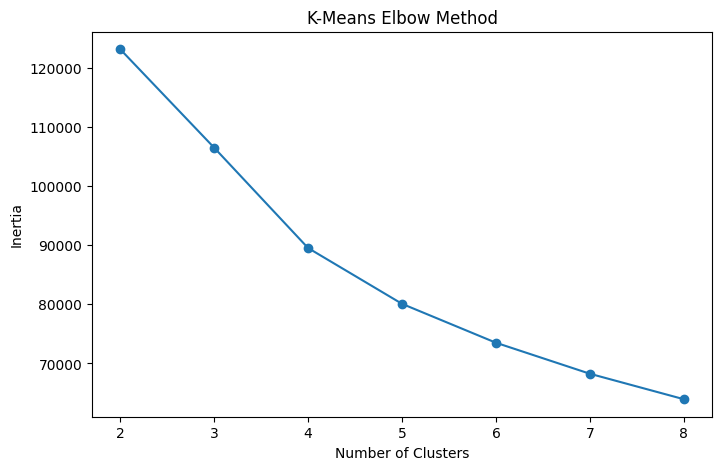

In [7]:
#Plot:

plt.figure(figsize=(8,5))

plt.plot(
    range(2,9),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.show()

In [8]:
#K-Means Model

#Suppose we choose:

#K = 3

#Then:

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_cluster
)

In [9]:
#Analyze:

df.groupby("Cluster").agg({
    "Claim_Amount": "mean",
    "Patient_Age": "mean",
    "Number_of_Procedures": "mean",
    "Length_of_Stay_Days": "mean",
    "Is_Fraudulent": "mean"
})

#This tells you what each cluster represents.

,Claim_Amount,Patient_Age,Number_of_Procedures,Length_of_Stay_Days,Is_Fraudulent
Cluster,,,,,
0,1.240899e+06,45.141739,5.501378,5.003637,0.24380
1,1.248986e+06,45.067598,5.517920,4.953362,0.25397
2,1.294285e+06,58.000000,4.833333,4.166667,0.00000


In [11]:
"""
For example:

Cluster 0 → lower/moderate claim behavior
Cluster 1 → higher observed fraud rate
Cluster 2 → higher claim-value behavior

The exact interpretation must come from the calculated cluster statistics. """

'\nFor example:\n\nCluster 0 → lower/moderate claim behavior\nCluster 1 → higher observed fraud rate\nCluster 2 → higher claim-value behavior\n\nThe exact interpretation must come from the calculated cluster statistics. '

In [12]:
#Silhouette Score
score = silhouette_score(
    X_cluster,
    df["Cluster"]
)

print("Silhouette Score:", score)

Silhouette Score: 0.12209733139732809


In [13]:
"""
Explanation

Silhouette score helps evaluate how well separated the clusters are.

Closer to 1 generally indicates better separation. """

'\nExplanation\n\nSilhouette score helps evaluate how well separated the clusters are.\n\nCloser to 1 generally indicates better separation. '

In [14]:
#Statistical Test

#Now we add proper foundation statistics.

#Chi-square test

#Question:

#Is provider type associated with fraud status?

contingency_table = pd.crosstab(
    df["Provider_Type"],
    df["Is_Fraudulent"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 2265.0295039663542
p-value: 0.0


In [15]:
#Interpretation:

alpha = 0.05

if p_value < alpha:
    print(
        "There is statistically significant evidence "
        "of an association between provider type and fraud status."
    )
else:
    print(
        "There is insufficient statistical evidence "
        "of an association."
    )

#This is much better than simply saying:

#"Provider type causes fraud."

#We are only testing association.

There is statistically significant evidence of an association between provider type and fraud status.


In [16]:
#Business Risk Indicators

#Create analyst-friendly flags.

df["High_Value_Claim"] = (
    df["Claim_Amount"] >
    df["Claim_Amount"].quantile(0.90)
)

In [17]:
#Late claim:

df["Late_Submission_Risk"] = (
    df["Claim_Submitted_Late"] == True
)

In [18]:
#Multiple procedures:

df["Multiple_Procedure_Risk"] = (
    df["Number_of_Procedures"] >= 5
)

In [19]:
#Previous claims:

df["Frequent_Patient"] = (
    df["Number_of_Previous_Claims_Patient"] >= 3
)

In [20]:
df[
    [
        "High_Value_Claim",
        "Late_Submission_Risk",
        "Multiple_Procedure_Risk",
        "Frequent_Patient",
        "Is_Fraudulent"
    ]
].corr()

#This helps investigate whether these indicators are associated with fraud.

,High_Value_Claim,Late_Submission_Risk,Multiple_Procedure_Risk,Frequent_Patient,Is_Fraudulent
High_Value_Claim,1.000000,-0.005100,-0.028240,NaN,-0.020355
Late_Submission_Risk,-0.005100,1.000000,0.003895,NaN,0.015432
Multiple_Procedure_Risk,-0.028240,0.003895,1.000000,NaN,0.105411
Frequent_Patient,NaN,NaN,NaN,NaN,NaN
Is_Fraudulent,-0.020355,0.015432,0.105411,NaN,1.000000


In [21]:
#Final Business Analysis

#Now answer actual business questions.

#Question 1

#What percentage of claims are fraudulent?

df["Is_Fraudulent"].mean() * 100

np.float64(24.930348258706466)

In [22]:
#Question 2

#Which provider types have higher observed fraud rates?

df.groupby("Provider_Type")[
    "Is_Fraudulent"
].mean().sort_values(
    ascending=False
) * 100

Provider_Type
Specialist Office    49.881983
Urgent Care          16.996047
Clinic               16.777630
Hospital             16.520861
Laboratory           16.061644
Pharmacy             16.050584
Name: Is_Fraudulent, dtype: float64

In [23]:
#Question 3

#Which specialties have higher observed fraud rates?

df.groupby("Provider_Specialty")[
    "Is_Fraudulent"
].mean().sort_values(
    ascending=False
) * 100

Provider_Specialty
Cardiology          46.549875
Orthopedics         45.652174
General Practice    17.790368
Pediatrics          17.540891
Physical Therapy    17.344173
Neurology           16.979111
Psychiatry          16.778149
Oncology            16.767455
Radiology           16.164818
Dermatology         16.148391
Name: Is_Fraudulent, dtype: float64

In [24]:
#Question 4

#Are high-value claims more associated with fraud?

df.groupby("High_Value_Claim")[
    "Is_Fraudulent"
].mean() * 100

High_Value_Claim
False    25.223881
True     22.288557
Name: Is_Fraudulent, dtype: float64

In [25]:
#Question 5

#Does late submission have an association with fraud?

df.groupby("Claim_Submitted_Late")[
    "Is_Fraudulent"
].mean() * 100

Claim_Submitted_Late
False    24.006382
True     25.412691
Name: Is_Fraudulent, dtype: float64

In [26]:
#Question 6

#Which service types show higher observed fraud rates?

df.groupby("Service_Type")[
    "Is_Fraudulent"
].mean().sort_values(
    ascending=False
) * 100

Service_Type
Laboratory        28.152141
Emergency Room    27.170036
Ambulance         27.078385
Outpatient        26.375598
Pharmacy          26.309594
Inpatient         14.268330
Name: Is_Fraudulent, dtype: float64

In [27]:
""" STEP 42 — Power BI

Now take the cleaned dataset and create your dashboard.

Page 1 — Claims Overview

Cards:

Total Claims
Total Claim Amount
Average Claim Amount
Fraudulent Claims
Fraud Rate

Charts:

Monthly Claim Trend
Claims by Provider Type
Claims by Service Type
Claim Amount Distribution
Page 2 — Fraud Analysis

Cards:

Fraudulent Claims
Genuine Claims
Fraud Rate
Average Fraudulent Claim

Charts:

Fraud Rate by Provider Type
Fraud Rate by Specialty
Fraud Rate by Service Type
Fraud Rate by Admission Type
Fraud Trend
Page 3 — Provider & Risk Analysis

Charts:

Top providers by claim amount
High-value claims
Claims by specialty
Previous claims vs fraud
Claim amount vs procedures
Late submission vs fraud """

' STEP 42 — Power BI\n\nNow take the cleaned dataset and create your dashboard.\n\nPage 1 — Claims Overview\n\nCards:\n\nTotal Claims\nTotal Claim Amount\nAverage Claim Amount\nFraudulent Claims\nFraud Rate\n\nCharts:\n\nMonthly Claim Trend\nClaims by Provider Type\nClaims by Service Type\nClaim Amount Distribution\nPage 2 — Fraud Analysis\n\nCards:\n\nFraudulent Claims\nGenuine Claims\nFraud Rate\nAverage Fraudulent Claim\n\nCharts:\n\nFraud Rate by Provider Type\nFraud Rate by Specialty\nFraud Rate by Service Type\nFraud Rate by Admission Type\nFraud Trend\nPage 3 — Provider & Risk Analysis\n\nCharts:\n\nTop providers by claim amount\nHigh-value claims\nClaims by specialty\nPrevious claims vs fraud\nClaim amount vs procedures\nLate submission vs fraud '

In [32]:
#Final Project Architecture or Workflow:
"""
                        HEALTH INSURANCE CLAIMS DATA
                              │
                              ▼
                    ┌───────────────────┐
                    │   Data Source     │
                    │   CSV Dataset     │
                    └─────────┬─────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │ 1. Data Understanding  │
                 │    Pandas + NumPy      │
                 └────────────┬───────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │ 2. Data Cleaning       │
                 │                        │
                 │ Missing Values         │
                 │ Duplicates             │
                 │ Data Types             │
                 │ Invalid Values         │
                 │ Outliers               │
                 └────────────┬───────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │ 3. Feature Engineering │
                 │                        │
                 │ Date Features          │
                 │ Claim Features         │
                 │ Provider Features      │
                 │ Risk Indicators        │
                 └────────────┬───────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │ 4. Statistical         │
                 │    Analysis             │
                 │                        │
                 │ Mean / Median / Mode   │
                 │ Min / Max / Range      │
                 │ Variance / Std Dev     │
                 │ Percentiles / Quartiles│
                 │ IQR / Correlation      │
                 └────────────┬───────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │ 5. EDA & Visualization │
                 │                        │
                 │ Pandas                 │
                 │ Matplotlib             │
                 │ Seaborn                │
                 └────────────┬───────────┘
                              │
               ┌──────────────┴──────────────┐
               │                             │
               ▼                             ▼
      ┌──────────────────┐         ┌────────────────────┐
      │ 6. SQL Business  │         │ 7. Machine         │
      │    Analysis      │         │    Learning        │
      │                  │         │                    │
      │ MySQL            │         │ Classification     │
      │ Queries          │         │ Clustering         │
      │ Business Report  │         │ Regression        │
      └────────┬─────────┘         └──────────┬─────────┘
               │                              │
               │                    ┌─────────┴─────────┐
               │                    │                   │
               │                    ▼                   ▼
               │             Classification       K-Means
               │                    │             Clustering
                                                     |
               │                    ▼               Customer segmentation
               │             Fraud Detection
               │
               └──────────────┬───────────────┐
                              │               │
                              ▼               ▼
                       ┌────────────┐   ┌──────────────┐
                       │ Business   │   │ ML Results   │
                       │ Insights   │   │ Evaluation   │
                       └─────┬──────┘   └──────┬───────┘
                             │                 │
                             └────────┬────────┘
                                      ▼
                              ┌───────────────┐
                              │ 8. Power BI   │
                              │ Dashboard     │
                              └───────┬───────┘
                                      │
                                      ▼
                              ┌───────────────┐
                              │ Final Business│
                              │ Report        │
                              └───────────────┘  """

'\n                        HEALTH INSURANCE CLAIMS DATA\n                              │\n                              ▼\n                    ┌───────────────────┐\n                    │   Data Source     │\n                    │   CSV Dataset     │\n                    └─────────┬─────────┘\n                              │\n                              ▼\n                 ┌────────────────────────┐\n                 │ 1. Data Understanding  │\n                 │    Pandas + NumPy      │\n                 └────────────┬───────────┘\n                              │\n                              ▼\n                 ┌────────────────────────┐\n                 │ 2. Data Cleaning       │\n                 │                        │\n                 │ Missing Values         │\n                 │ Duplicates             │\n                 │ Data Types             │\n                 │ Invalid Values         │\n                 │ Outliers               │\n                 └────────────┬──

In [30]:
"""
The six ML algorithms
1. Logistic Regression → Fraud Classification
2. KNN                → Fraud Classification
3. Decision Tree      → Fraud Classification
4. Random Forest      → Fraud Classification
5. Linear Regression  → Claim Amount Prediction
6. K-Means            → Claim/Patient Segmentation """

'\nThe six ML algorithms\n1. Logistic Regression → Fraud Classification\n2. KNN                → Fraud Classification\n3. Decision Tree      → Fraud Classification\n4. Random Forest      → Fraud Classification\n5. Linear Regression  → Claim Amount Prediction\n6. K-Means            → Claim/Patient Segmentation '